## 1. Imports


In [2]:
# imports + constants: buildings, DIA sector, colour classes, grid
import io
import os
import zipfile
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter


## 2. Environment & data location


In [3]:
import sys
print("Python", sys.version.split()[0],
      "| numpy", np.__version__, "| scipy", __import__("scipy").__version__,
      "| matplotlib", __import__("matplotlib").__version__,
      "| h5py", h5py.__version__)

_candidates = ([Path(os.environ["WTV_DATA_DIR"])] if "WTV_DATA_DIR" in os.environ
               else []) + [Path("../Dataset for Visualization"),
                           Path("Dataset for Visualization")]
DATA_DIR = next((p for p in _candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset folder not found. Either place the notebook so that "
        "'../Dataset for Visualization' exists (folder with the "
        "*_statistical_dataset.h5 files), or set the environment variable "
        "WTV_DATA_DIR to the folder's absolute path before running this cell.")
print("DATA_DIR ->", DATA_DIR.resolve())
OUT_DIR = Path(".")                     


Python 3.13.7 | numpy 2.3.3 | scipy 1.16.2 | matplotlib 3.10.7 | h5py 3.16.0
DATA_DIR -> C:\Users\mbura\OneDrive\Belgeler\Masaüstü\Master Thesis and Wind Tunnel Data Visualization\Wind Tunnel Visualization\Dataset for Visualization


## 3. Study constants

In [ ]:
# ---- building inventory: 4 parapet groups x 6 geometries = 24 buildings -----
PARAPETS = [("A0", "no parapet"), ("A0025", "hp/h=0.025"),
            ("A005", "hp/h=0.05"), ("A01", "hp/h=0.10")]
GEOMS = [("H1L1", "L1"), ("H1L2", "L2"), ("H1L3", "L3"),
         ("H2L1", "L1"), ("H2L2", "L2"), ("H2L3", "L3")]
BUILDINGS = [(p, g, k) for p, _ in PARAPETS for g, k in GEOMS]

# ---- the three directional sectors (data paper Sec. 2.5, table, Professors Data Paper with Richard) -------------
# Each sector = list of (angle indices, (sign_t, sign_s)) groups; every group's
# fields are reflected by the signs BEFORE pooling so that all fields of a
# sector describe ONE wind-relative situation. All mirror rules were verified
# empirically on raw data in the per-direction notebooks:
#   PAR : windward gable edge at t = -0.5          (10 fields)
#   PERP: Wall+ = windward face, symmetric in t    (20 fields; bands pooled 2x)
#   DIAG: windward corner at (t, s) = (-0.5, +0.5) (20 fields)
SECTORS = {
    "PAR":  [([30, 31, 0, 1, 2], (+1, +1)),
             ([14, 15, 16, 17, 18], (-1, +1))],
    "PERP": [([6, 7, 8, 9, 10], (+1, +1)), ([6, 7, 8, 9, 10], (-1, +1)),
             ([22, 23, 24, 25, 26], (+1, -1)),
             ([22, 23, 24, 25, 26], (-1, -1))],
    "DIAG": [([2, 3, 4, 5, 6], (+1, +1)), ([10, 11, 12, 13, 14], (-1, +1)),
             ([26, 27, 28, 29, 30], (+1, -1)),
             ([18, 19, 20, 21, 22], (-1, -1))],
}
SECTOR_ORDER = ["PAR", "PERP", "DIAG"]
AGG = np.nanmean          # sector aggregate; np.nanmedian = data-paper default


STATS = {
    "cpm":   dict(col="Cp_mean", meas=["CP-10"],
                  edges=np.array([-2.0, -1.25, -0.5, 0.25, 1.0]),
                  title=r"$c_{p,m}$",
                  label=r"$c_{p,m}$  class  [-]", fmt="+.2f",
                  note=("identical for $c_{p,10}$ and $c_{p,1}$, as "
                        "$c_{p,m}$ refers to the mean — which is unaffected "
                        "by the TVL area-averaging filter")),
    "sigma": dict(col="Deviation", meas=["CP-10", "CP-1"],
                  edges=np.array([0.0, 0.075, 0.15, 0.225, 0.30]),
                  title=r"$\sigma(c_p)$",
                  label=r"$\sigma(c_p)$  class  [-]", fmt=".3f",
                  note=("one class scale for both rows (datasheet basis "
                        "0…0.30) — the $c_{p,10}$ row shows the damping of "
                        "fluctuations by the larger tributary area")),
    "skew":  dict(col="Skewness", meas=["CP-10", "CP-1"],
                  edges=np.array([-2.0, -1.25, -0.5, 0.25, 1.0]),
                  title=r"skewness$(c_p)$",
                  label=r"skewness$(c_p)$  class  [-]", fmt="+.2f",
                  note=("same class boundaries as the $c_{p,m}$ page; a "
                        "Gaussian signal (skewness 0) falls in the red "
                        "class — white/yellow mark suction-peak-prone zones, "
                        "blue positively skewed windward faces")),
    "kurt":  dict(col="Kurtosis", meas=["CP-10", "CP-1"],
                  edges=np.array([0.0, 1.0, 2.0, 3.0, 4.0]),
                  title=r"excess kurtosis$(c_p)$",
                  label=r"excess kurt.$(c_p)$  class  [-]", fmt=".1f",
                  note=("the dataset stores EXCESS kurtosis (Gaussian = 0; "
                        "verified: windward-wall values ≈ +0.4, minima < 0); "
                        "values outside 0…4 clip into the end classes — "
                        "red/blue mark strongly non-Gaussian, heavy-tailed "
                        "zones")),
}
PAGE_ORDER = ["cpm", "sigma", "skew", "kurt"]

COLORS_RGB = [(1.0, 1.0, 1.0),   # class 0 white
              (1.0, 1.0, 0.0),   # class 1 yellow
              (1.0, 0.0, 0.0),   # class 2 red
              (0.0, 0.0, 1.0)]   # class 3 blue
COLOR_NAMES = ["white", "yellow", "red", "blue"]

# ---- common unfolded grid ----------------------------------------------------
TI = np.linspace(-0.5, 0.5, 120)     # t = x/L
SI = np.linspace(-1.5, 1.5, 360)     # s = y/B + z/H (unwinded)
TG, SG = np.meshgrid(TI, SI)


## 4. Data access functions (HDF5)

In [5]:
# ---- HDF reading -------------------------------------------------------------
def open_h5(path):
    """Open an .h5 file, or the single .h5 member inside a .zip."""
    path = str(path)
    if path.endswith(".zip"):
        z = zipfile.ZipFile(path)
        member = [n for n in z.namelist() if n.endswith(".h5")][0]
        return h5py.File(io.BytesIO(z.read(member)), "r")
    return h5py.File(path, "r", locking=False)


def side_s(name, gy, gz, Wy, H):
    """Unfolded perimeter coordinate s from the tap side letter (N/P/M)."""
    sd = name.split("-")[1]
    if sd == "N":
        return gy / Wy               # roof  : s in [-0.5, 0.5]
    if sd == "P":
        return 1.5 - gz / H          # Wall+ : s in [ 0.5, 1.5]
    if sd == "M":
        return -1.5 + gz / H         # Wall- : s in [-1.5,-0.5]
    raise ValueError(name)


# the three sectors together touch every measured direction
NEEDED_ANGLES = sorted({a for groups in SECTORS.values()
                        for grp, _ in groups for a in grp})
# (column, measurement group) pairs actually needed
NEEDED_PAIRS = sorted({(d["col"], m) for d in STATS.values()
                       for m in d["meas"]})
NEEDED_MEAS = sorted({m for _, m in NEEDED_PAIRS})


def read_stats(path):
    """One campaign file -> (t, s, {(col, meas): cp[32, n_tap]}) for every
    needed statistic/measurement-group pair. Columns are resolved BY NAME
    from the `Index` attribute (13-col B-reference and 14-col C-reference
    layouts both work)."""
    f = open_h5(path)
    O = f["Info/Geometry/Original"][()]
    Lx = O["GlobalX"].max() - O["GlobalX"].min()
    Wy = O["GlobalY"].max() - O["GlobalY"].min()
    H  = O["GlobalZ"].max() - O["GlobalZ"].min()
    pos = {}
    for row in O:
        if row["IsMeasurementPoint"] == 1:
            nm = row["PointID"]
            nm = nm.decode() if isinstance(nm, bytes) else nm
            pos[nm] = (float(row["GlobalX"]), float(row["GlobalY"]),
                       float(row["GlobalZ"]))
    angles = sorted(k for k in f.keys() if k != "Info")
    names = sorted(n for n in f[angles[0]]["CP-10"].keys() if n in pos)
    ci = {}
    cp = {pair: np.full((32, len(names)), np.nan) for pair in NEEDED_PAIRS}
    for ai in NEEDED_ANGLES:
        for meas in NEEDED_MEAS:
            g = f[angles[ai]][meas]
            cols_here = [(c, m) for (c, m) in NEEDED_PAIRS if m == meas]
            for ni, n in enumerate(names):
                d = g[n]
                if meas not in ci:
                    idx = [x.decode() if isinstance(x, bytes) else x
                           for x in d.attrs["Index"]]
                    ci[meas] = {c: idx.index(c) for c, _ in cols_here}
                v = np.asarray(d[()], dtype=float)
                for c, m in cols_here:
                    cp[(c, m)][ai, ni] = v[ci[meas][c]]
    f.close()
    t = np.array([pos[n][0] / Lx for n in names])
    s = np.array([side_s(n, pos[n][1], pos[n][2], Wy, H) for n in names])
    return t, s, cp


def sources(prefix, geom, kind):
    """Campaign file(s) of one building (L3 = edge + centre campaigns)."""
    base = prefix + geom
    if kind in ("L1", "L2"):
        return [DATA_DIR / f"{base}_statistical_dataset.h5"]
    out = [DATA_DIR / f"{base}_edge_statistical_dataset.h5"]
    for cand in (DATA_DIR / f"{base}_center_statistical_dataset.h5",
                 DATA_DIR / f"{base}_center_dataset.zip"):
        if cand.exists():
            out.append(cand)
            break
    return out


## 5. Pooling & gridding functions

In [6]:
# ---- pooling: grid each angle once per statistic, mirrors = array flips -----
from scipy.spatial import Delaunay, cKDTree
from scipy.interpolate import LinearNDInterpolator


def refl(a):
    """Angle index reflected through the mid-length plane (theta -> 180-theta),
    used to complete the un-instrumented half of L2/L3 models."""
    return (16 - a) % 32


def angle_points(t, s, cp, a, complete):
    """Scattered points of angle a; `complete` mirror-reconstructs the
    un-instrumented half (L2 + L3 campaigns) from angle refl(a)."""
    T, S, V = [t], [s], [cp[a]]
    if complete:
        T.append(-t); S.append(s); V.append(cp[refl(a)])
    return np.concatenate(T), np.concatenate(S), np.concatenate(V)


def make_gridder(T, S, smooth=3.0):
    """The tap POSITIONS of a building are the same for every wind angle and
    every statistic — only the values change. So triangulate once and reuse:
    returns a function V -> gridded field (linear interpolation + nearest
    fill + Gaussian smoothing, numerically identical to scipy `griddata`,
    which uses the same Delaunay triangulation internally)."""
    pts = np.column_stack([T, S])
    tri = Delaunay(pts)
    _, nearest = cKDTree(pts).query(np.column_stack([TG.ravel(), SG.ravel()]))

    def grid(V):
        Z = LinearNDInterpolator(tri, V)(TG, SG)
        Z = np.where(np.isnan(Z), V[nearest].reshape(TG.shape), Z)
        return gaussian_filter(Z, sigma=smooth, mode="nearest") if smooth else Z
    return grid


def grid_one(T, S, V, smooth=3.0):
    """One-off gridding (kept for spot checks; the pipeline uses make_gridder)."""
    Z = griddata((T, S), V, (TG, SG), method="linear")
    Zn = griddata((T, S), V, (TG, SG), method="nearest")
    Z = np.where(np.isnan(Z), Zn, Z)
    return gaussian_filter(Z, sigma=smooth, mode="nearest") if smooth else Z


def flip(Z, sign_t, sign_s):
    """Apply a sector mirror to an already-gridded field. Because TI and SI
    are symmetric about 0, reflecting the scattered points and re-gridding is
    identical to flipping the gridded array."""
    if sign_t < 0:
        Z = Z[:, ::-1]
    if sign_s < 0:
        Z = Z[::-1, :]
    return Z


def building_sector_means(prefix, geom, kind):
    """All sector-mean fields of one building for every statistic pair.
    Returns {(sector, stat_key, meas): 2-D field}."""
    camps = [read_stats(p) for p in sources(prefix, geom, kind)]
    complete = kind != "L1"                  # L2/L3 are half-instrumented
    # one shared triangulation (positions are angle- and column-independent)
    T0, S0, _ = angle_points(camps[0][0], camps[0][1],
                             camps[0][2][NEEDED_PAIRS[0]], NEEDED_ANGLES[0],
                             complete)
    if len(camps) > 1:
        T1, S1, _ = angle_points(camps[1][0], camps[1][1],
                                 camps[1][2][NEEDED_PAIRS[0]],
                                 NEEDED_ANGLES[0], complete)
        T0, S0 = np.concatenate([T0, T1]), np.concatenate([S0, S1])
    gridder = make_gridder(T0, S0)

    base = {}                                # (pair, angle) -> gridded field
    for pair in NEEDED_PAIRS:
        for a in NEEDED_ANGLES:
            Vs = []
            for (t, s, cp) in camps:
                _, _, V = angle_points(t, s, cp[pair], a, complete)
                Vs.append(V)
            base[(pair, a)] = gridder(np.concatenate(Vs))

    out = {}
    for sector, groups in SECTORS.items():
        for skey, sdef in STATS.items():
            for meas in sdef["meas"]:
                pair = (sdef["col"], meas)
                fields = [flip(base[(pair, a)], st, ss)
                          for grp, (st, ss) in groups for a in grp]
                out[(sector, skey, meas)] = AGG(np.stack(fields), axis=0)
    return out


def to_layer(Z, edges):
    """Statistic field -> integer classes 0..3 over the given boundaries."""
    Zc = np.clip(Z, edges[0] + 1e-9, edges[-1] - 1e-9)
    return np.digitize(Zc, edges[1:-1]).astype(np.uint8)


## 6. Gridder consistency check (i would say optional, i just did for a random check.)


In [ ]:
# ---- consistency check: fast gridder == reference gridder for A0H1L1 ( totally optional, i just wanted to random check.) -------------------
# The pipeline triangulates each building once and reuses it for all
# angles/statistics (much faster). Verify on one real case that this gives
# the same field as the straightforward scipy.griddata reference, and that
# the sector means reproduce the earlier per-direction deliverables.
_t, _s, _cp = read_stats(sources("A0", "H1L1", "L1")[0])
_pair = ("Cp_mean", "CP-10")
_T, _S, _V = angle_points(_t, _s, _cp[_pair], 8, complete=False)
_ref = grid_one(_T, _S, _V)
_fast = make_gridder(_T, _S)(_V)
_dev = float(np.abs(_ref - _fast).max())
print(f"fast gridder vs griddata reference (A0H1L1, 90 deg, cp,m): "
      f"max |difference| = {_dev:.2e}")
assert _dev < 1e-6, "gridder mismatch"
del _t, _s, _cp, _T, _S, _V, _ref, _fast


fast gridder vs griddata reference (A0H1L1, 90 deg, cp,m): max |difference| = 0.00e+00


## 7. Load the data (loading the data, and checking myself with the previous versions whether they make sense or not.)

Runs the pipeline for every building and prints the sector-mean ranges per statistic and CP-group, then cross-checks the cp,m and σ(cp,10) ranges against the earlier deliverables (they match exactly).


In [8]:
# ---- build all 24 buildings x 3 sectors x 4 statistics ----------------------
# early check first: are all 32 campaign files reachable?
_missing = [Path(p).name for prefix, geom, kind in BUILDINGS
            for p in sources(prefix, geom, kind) if not Path(p).exists()]
if _missing:
    raise FileNotFoundError(
        f"{len(_missing)} dataset file(s) missing in '{DATA_DIR}':\n  "
        + "\n  ".join(_missing))
print("all campaign files found")

LAYERS, LABELS = {}, []       # LAYERS[(sector, stat, meas)] = [24 class maps]
_rng = {}
for prefix, geom, kind in BUILDINGS:
    name = prefix + geom
    means = building_sector_means(prefix, geom, kind)
    for key, Z in means.items():
        skey = key[1]
        LAYERS.setdefault(key, []).append(to_layer(Z, STATS[skey]["edges"]))
        lo, hi = _rng.get(key, (np.inf, -np.inf))
        _rng[key] = (min(lo, Z.min()), max(hi, Z.max()))
    LABELS.append(name)
    print(f"  {name} done", flush=True)

print(f"\n{len(LABELS)} buildings ready; sector-mean ranges over all buildings:")
for skey in PAGE_ORDER:
    for meas in STATS[skey]["meas"]:
        row = "  ".join(f"{sec}: {_rng[(sec, skey, meas)][0]:+.3f}.."
                        f"{_rng[(sec, skey, meas)][1]:+.3f}"
                        for sec in SECTOR_ORDER)
        print(f"  {skey:6s} {meas:6s} | {row}")

# cross-check against the earlier deliverables (cp,m and sigma CP-10 pages)
_prev = {("PAR", "cpm", "CP-10"): (-1.340, +0.351),
         ("PERP", "cpm", "CP-10"): (-1.396, +0.946),
         ("DIAG", "cpm", "CP-10"): (-2.218, +0.611),
         ("PAR", "sigma", "CP-10"): (+0.020, +0.178),
         ("PERP", "sigma", "CP-10"): (+0.028, +0.185),
         ("DIAG", "sigma", "CP-10"): (+0.029, +0.265)}
_bad = [k for k, (lo, hi) in _prev.items()
        if abs(_rng[k][0] - lo) > 0.005 or abs(_rng[k][1] - hi) > 0.005]
print("cross-check vs earlier deliverables:",
      "OK (all ranges reproduced)" if not _bad else f"MISMATCH {_bad}")


all campaign files found
  A0H1L1 done
  A0H1L2 done
  A0H1L3 done
  A0H2L1 done
  A0H2L2 done
  A0H2L3 done
  A0025H1L1 done
  A0025H1L2 done
  A0025H1L3 done
  A0025H2L1 done
  A0025H2L2 done
  A0025H2L3 done
  A005H1L1 done
  A005H1L2 done
  A005H1L3 done
  A005H2L1 done
  A005H2L2 done
  A005H2L3 done
  A01H1L1 done
  A01H1L2 done
  A01H1L3 done
  A01H2L1 done
  A01H2L2 done
  A01H2L3 done

24 buildings ready; sector-mean ranges over all buildings:
  cpm    CP-10  | PAR: -1.340..+0.351  PERP: -1.396..+0.946  DIAG: -2.218..+0.611
  sigma  CP-10  | PAR: +0.020..+0.178  PERP: +0.028..+0.185  DIAG: +0.029..+0.265
  sigma  CP-1   | PAR: +0.022..+0.191  PERP: +0.030..+0.197  DIAG: +0.031..+0.279
  skew   CP-10  | PAR: -1.413..+0.567  PERP: -1.200..+0.749  DIAG: -1.832..+0.777
  skew   CP-1   | PAR: -1.345..+0.579  PERP: -1.183..+0.771  DIAG: -1.850..+0.807
  kurt   CP-10  | PAR: -0.133..+8.290  PERP: -0.160..+4.155  DIAG: -0.033..+9.970
  kurt   CP-1   | PAR: -0.016..+8.547  PERP: -0.110

## 8. Chart function

`plot_stat_page(stat)` draws one page: rows = CP-groups (1 or 2), columns = PAR | PERP | DIAG, wind-orientation arrows beside the titles, one shared discrete colourbar, and the page's scale note in the caption.


In [ ]:
# ---- the one-page-per-statistic chart (1 or 2 rows x 3 sector columns) ------
FONTSIZE = 10


def layer_rgba(layer, alpha):
    pal = np.asarray(COLORS_RGB, dtype=float)
    rgba = np.zeros((*layer.shape, 4))
    rgba[..., :3] = pal[layer]
    rgba[..., 3] = alpha
    return rgba


def _wind_glyph(ax, sector):
    """Small wind-orientation arrow next to the panel title (pooled frames:
    PAR from the left, PERP onto Wall+ from above, DIAG onto the upper-left
    corner). Drawn in axes-fraction coordinates above the panel."""
    ap = dict(arrowstyle="-|>", color="0.25", lw=1.4)
    if sector == "PAR":
        ax.annotate("", xy=(0.40, 1.045), xytext=(0.26, 1.045),
                    xycoords="axes fraction", annotation_clip=False,
                    arrowprops=ap)
    elif sector == "PERP":
        ax.annotate("", xy=(0.335, 1.015), xytext=(0.335, 1.10),
                    xycoords="axes fraction", annotation_clip=False,
                    arrowprops=ap)
    else:  # DIAG
        ax.annotate("", xy=(0.40, 1.015), xytext=(0.28, 1.095),
                    xycoords="axes fraction", annotation_clip=False,
                    arrowprops=ap)


def plot_stat_page(skey, fontsize=FONTSIZE, fig_width_cm=18.0):
    """One overview page for statistic `skey`: rows = measurement groups
    (CP-10 / CP-1 where they differ), columns = PAR | PERP | DIAG, one shared
    discrete colourbar."""
    sdef = STATS[skey]
    meas_list = sdef["meas"]
    nrows = len(meas_list)
    edges = sdef["edges"]
    n = len(LABELS)
    alpha = 2.2 / n
    plt.rcParams.update({"font.size": fontsize})
    fig_w = fig_width_cm / 2.54
    fig_h = fig_w * (0.60 if nrows == 1 else 1.12)
    fig, axes = plt.subplots(nrows, 3, figsize=(fig_w, fig_h), squeeze=False)

    for r, meas in enumerate(meas_list):
        for c, sector in enumerate(SECTOR_ORDER):
            ax = axes[r][c]
            for L in LAYERS[(sector, skey, meas)]:
                ax.imshow(layer_rgba(L, alpha), origin="lower",
                          extent=[TI.min(), TI.max(), SI.min(), SI.max()],
                          interpolation="nearest", aspect="auto", zorder=2)
            ax.axhline(-0.5, color="w", lw=1.0, zorder=5)
            ax.axhline(0.5, color="w", lw=1.0, zorder=5)
            ax.set_xlim(-0.5, 0.5); ax.set_ylim(-1.5, 1.5)
            ax.set_box_aspect(1.4)
            ax.set_xticks([-0.5, 0.0, 0.5])
            if r == 0:
                ax.set_title(sector, pad=0.9 * fontsize, fontweight="bold")
                _wind_glyph(ax, sector)
            if r == nrows - 1:
                ax.set_xlabel(r"$t = x/L$")
            else:
                ax.tick_params(labelbottom=False)
            if c == 0:
                ax.set_yticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
            else:
                ax.set_yticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
                ax.tick_params(labelleft=False, length=0)
        if nrows > 1:                       # row label: which cp basis
            axes[r][0].text(-0.30, 0.5, ("$c_{p,10}$" if meas == "CP-10"
                                         else "$c_{p,1}$"),
                            transform=axes[r][0].transAxes, rotation=90,
                            va="center", ha="center", fontsize=fontsize,
                            fontweight="bold", color="#234")

    top = 0.90 if nrows == 1 else 0.945
    bottom = 0.18 if nrows == 1 else 0.10
    fig.subplots_adjust(left=0.125, right=0.845, top=top, bottom=bottom,
                        wspace=0.16, hspace=0.14)
    # one figure-level s-axis label (avoids colliding with the row tags)
    fig.text(0.028, (top + bottom) / 2, r"$s = y/B + z/H$ (unwinded)",
             rotation=90, va="center", ha="center", fontsize=fontsize)
    # region labels on the right of the last column (each row)
    bbox = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85)
    for r in range(nrows):
        for sc, txt in [(1.0, "Wall+"), (0.0, "Roof"), (-1.0, "Wall-")]:
            axes[r][2].text(0.56, sc, txt, rotation=90, va="center",
                            ha="center", fontsize=fontsize - 1.5, bbox=bbox,
                            clip_on=False)
    # one shared colourbar
    cmap = ListedColormap(COLORS_RGB)                                                ### fix here for the common colorbar 07.09.2026
    norm = BoundaryNorm(edges, cmap.N)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cax = fig.add_axes([0.875, 0.30 if nrows == 1 else 0.35,
                        0.020, 0.42 if nrows == 1 else 0.34])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_ticks(edges)
    cbar.set_ticklabels([format(e, sdef["fmt"]) for e in edges])
    cbar.ax.tick_params(labelsize=fontsize - 1.5)
    cbar.set_label(sdef["label"], fontsize=fontsize - 0.5)
    cbar.outline.set_linewidth(0.8)

    fig.suptitle(f"{sdef['title']}   —   {n} flat-roof buildings, "
                 "directional sectors of the data paper",
                 y=0.985, fontsize=fontsize + 1)
    fig.text(0.5, 0.012,
             "pooled results (mirrored orientation) — each building adds one "
             "transparent layer per panel, coloured by its class;\npure "
             "colour = all buildings agree, mixed colour = disagreement.  "
             "Note: " + sdef["note"],
             ha="center", va="bottom", fontsize=fontsize - 2, color="0.35")
    return fig


## 9. Render the four pages + final PDF

Pages: $c_{p,m}$ · $\sigma(c_p)$ · skewness · excess kurtosis → `All Statistics for Wind Tunnel Visualization.pdf`.


rendered page: cpm
rendered page: sigma
rendered page: skew
rendered page: kurt
wrote All Statistics for Wind Tunnel Visualization.pdf (4 pages: cpm / sigma / skew / kurt)


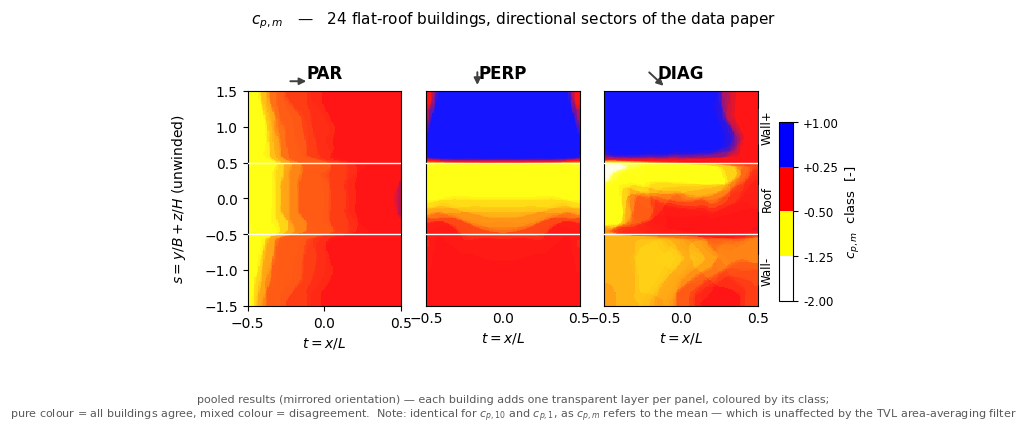

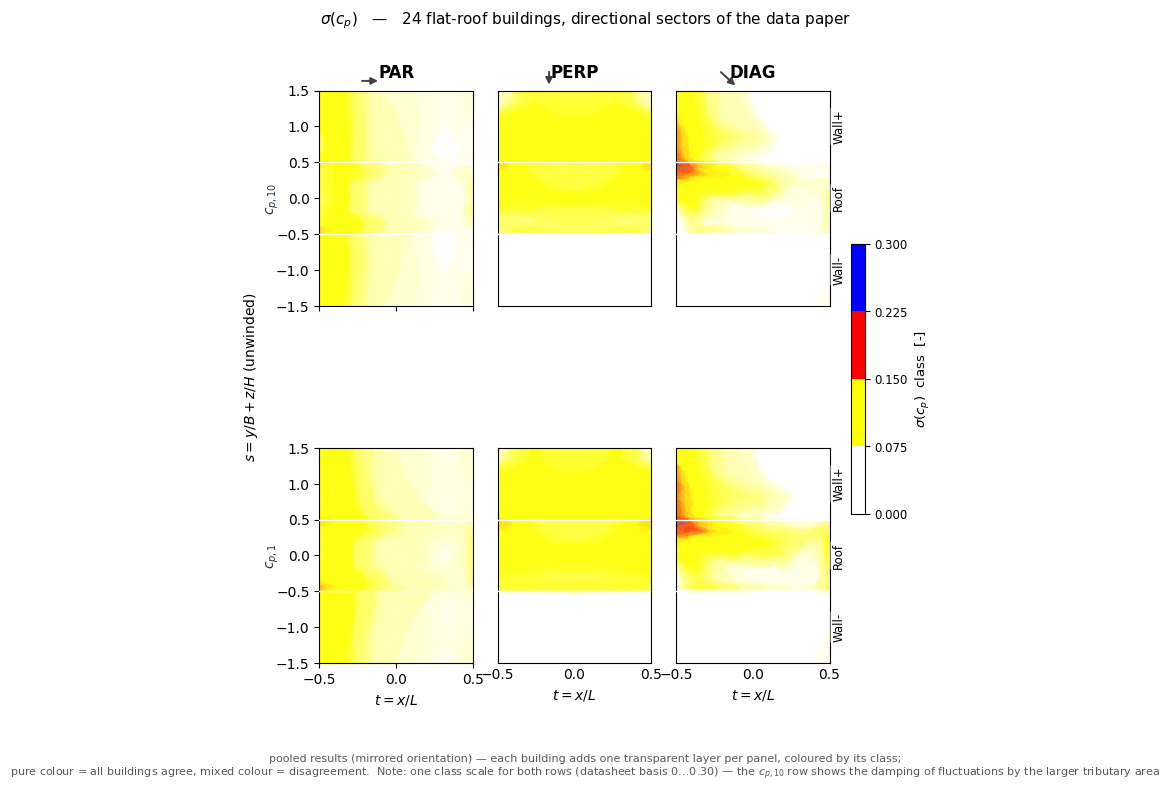

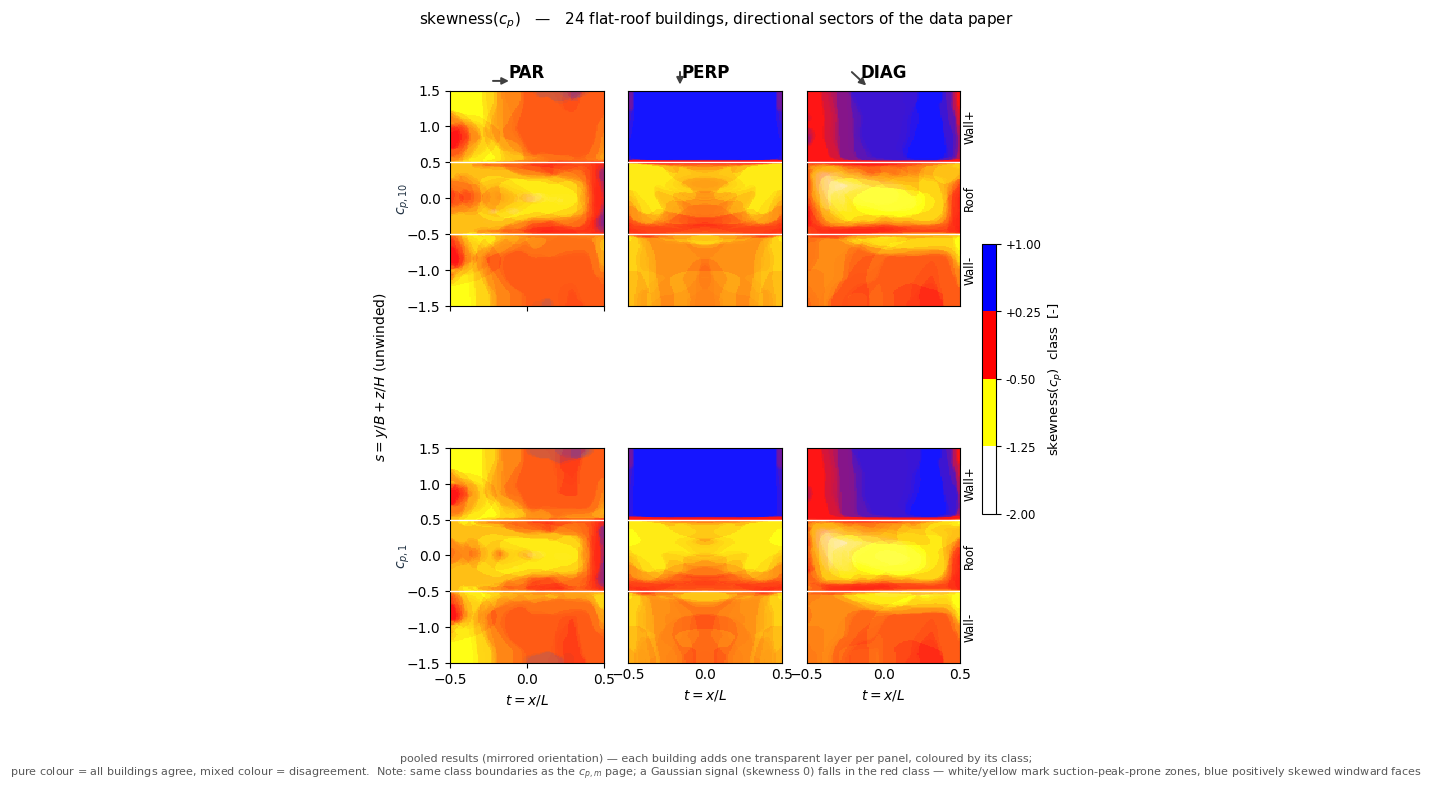

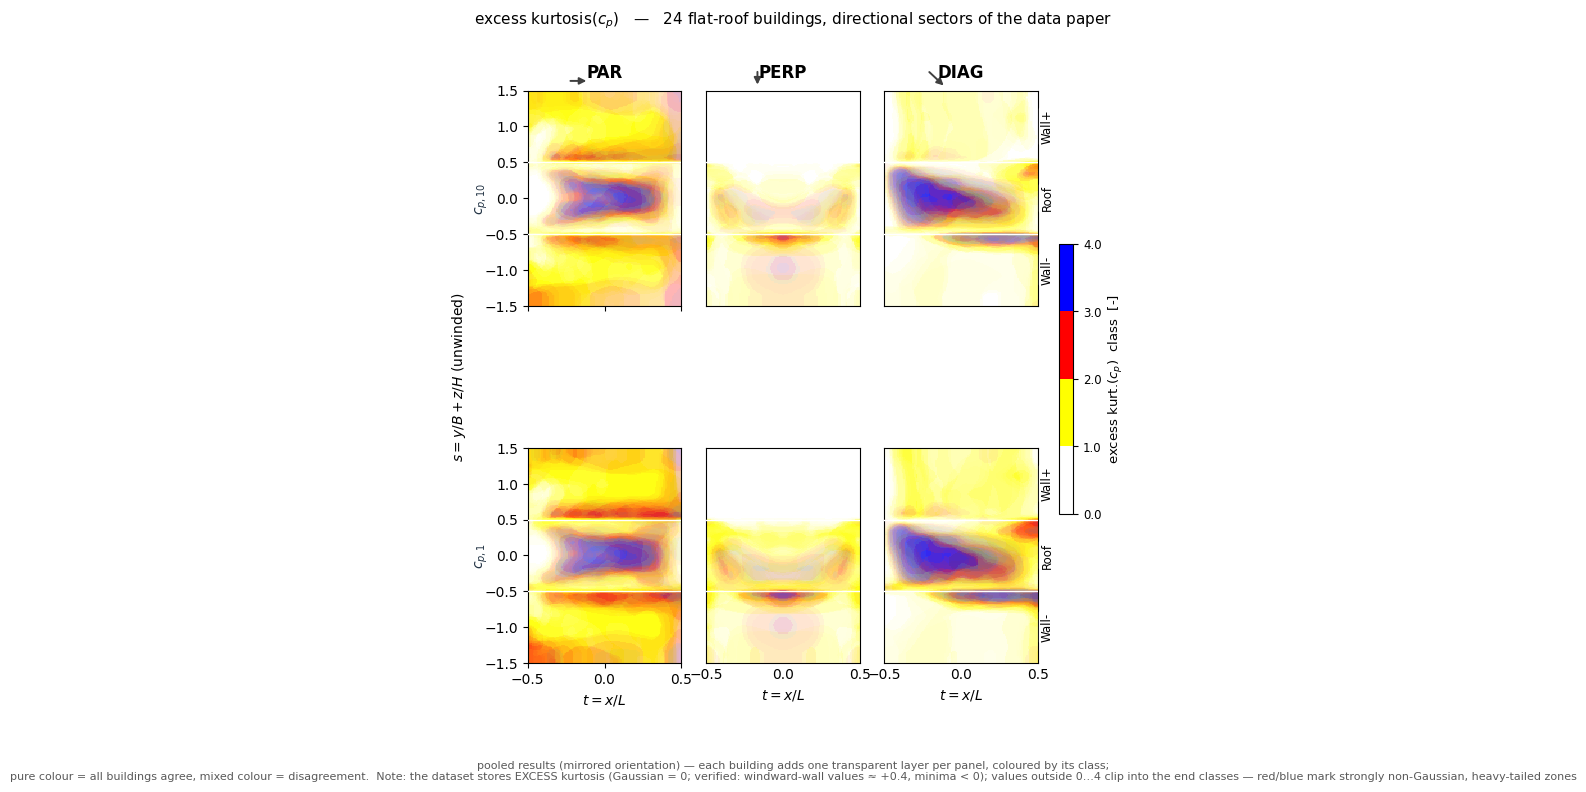

In [10]:
# ---- render the four pages and the final PDF --------------------------------
#  page 1: cp,m         page 2: sigma(cp)   (cp,10 + cp,1 rows)
#  page 3: skewness(cp) (cp,10 + cp,1)      page 4: excess kurtosis (both)
FIGS = {}
for skey in PAGE_ORDER:
    FIGS[skey] = plot_stat_page(skey)
    FIGS[skey].savefig(OUT_DIR / f"AllStats_{skey}.png",
                       dpi=170, bbox_inches="tight")
    print("rendered page:", skey)

pdf_path = OUT_DIR / "All Statistics for Wind Tunnel Visualization.pdf"
with PdfPages(pdf_path) as pdf:
    for skey in PAGE_ORDER:
        pdf.savefig(FIGS[skey], bbox_inches="tight")
print("wrote", pdf_path, f"({len(PAGE_ORDER)} pages: "
      + " / ".join(PAGE_ORDER) + ")")
plt.show()


## Next steps
- Feedback round with Prof. Kemper / Richard on the skewness and kurtosis
  class scales (chosen data-driven here; one-line switches in Section 3).
